# Q-learning swing-up of the unbalanced disk

Tabular Q-learning that learns to swing the disk up and balance it at the top, trained in simulation (`UnbalancedDiskDiscrete`) and deployed on the real setup (`UnbalancedDiskExp` via `runExp.py`).

**Notebook layout**
1. Imports
2. Wrappers & helpers (`UnbalancedDiskResetWrapper`, `Discretize_obs`, `argmax`, `roll_mean`)
3. `Qlearn` — the training loop (epsilon-greedy, decaying α, start-position curriculum, moving-average checkpointing)
4. Exploration-schedule plot
5. Training
6. Training-reward plot
7. Evaluation (deterministic, fixed start at the bottom)


In [1]:
import sys
import os
import numpy as np
import time
import warnings
warnings.filterwarnings("ignore")

from collections import defaultdict, deque
from gymnasium import spaces, Wrapper
import matplotlib.pyplot as plt
import gymnasium as gym

# make the local env importable
sys.path.append(os.path.expanduser("~/src/swingup/q_learning"))
from UnbalancedDiskDiscrete import UnbalancedDisk


In [2]:
class UnbalancedDiskResetWrapper(gym.Wrapper):
    """Normalise the env's reset() signature across Gymnasium versions."""
    def __init__(self, env): super().__init__(env)
    def reset(self, *, seed=None, options=None):
        try: obs, info = self.env.reset(seed=seed)
        except TypeError: obs, info = self.env.reset();
        return obs, info

class Discretize_obs(gym.Wrapper):
    """Discretise [theta, omega] to a state tuple for tabular Q-learning.

    Angle: NON-uniform grid -> FINE near the top (phi=0), coarse near the bottom
    (phi=+-pi). Velocity (omega): uniform over the observation_space range.
    nvec=[<ignored for angle>, n_omega]; fineness set by fine_w / fine_res / coarse_res.
    NOTE: the identical discretize() must also live in runExp.py, else deployment mismatches!
    """
    def __init__(self, env, nvec, fine_w=0.40, fine_res=0.025, coarse_res=0.10):
        super(Discretize_obs, self).__init__(env)
        o = env.observation_space
        self.omega_low  = float(o.low[1]);  self.omega_high = float(o.high[1])
        self.n_omega = int(np.array(nvec).flatten()[1])
        # non-uniform, top-centred angle edges
        pos = list(np.arange(0.0, fine_w, fine_res)) + list(np.arange(fine_w, np.pi, coarse_res)) + [np.pi]
        self.angle_edges = np.array(sorted(set([-e for e in pos] + pos)))
        self.n_angle = len(self.angle_edges) - 1
        self.observation_space = gym.spaces.MultiDiscrete([self.n_angle, self.n_omega])

    def discretize(self, observation):
        th = float(observation[0]); om = float(observation[1])
        phi = (th % (2 * np.pi)) - np.pi                                   # 0 = top, +-pi = bottom
        a = int(np.clip(np.searchsorted(self.angle_edges, phi, side='right') - 1, 0, self.n_angle - 1))
        om = np.clip(om, self.omega_low, self.omega_high)
        b = int(np.clip((om - self.omega_low) / (self.omega_high - self.omega_low) * self.n_omega, 0, self.n_omega - 1))
        return (a, b)

    def step(self, action):
        observation, reward, terminated, truncated, info = self.env.step(action)
        return self.discretize(observation), reward, terminated, truncated, info

    def reset(self, *args, **kwargs):
        obs, info = self.env.reset()
        return self.discretize(obs), info


def roll_mean(ar, start=2000, N=50):
    """Exponential moving average of ``ar`` (larger N = smoother)."""
    s = 1 - 1 / N
    k = start
    out = np.zeros(ar.shape)
    for i, a in enumerate(ar):
        k = s * k + (1 - s) * a
    return out

def argmax(a):
    """Index of the maximum value, breaking ties at random (avoids bias)."""
    a = np.array(a)
    return np.random.choice(np.arange(len(a), dtype=int)[a == np.max(a)])


In [3]:
def Qlearn(env, nsteps=5000, nvec_angle=360, nvec_rps=30, callbackfeq=5000,
           alpha=0.15, gamma=0.99, avg_window=8, checkpoint_name='best_Qmat.pkl', callback=None):
    """Tabular Q-learning for the discrete unbalanced disk.

    Learns a Q-table (dict ``(state, action) -> value``) with epsilon-greedy
    exploration and a TD(0) update. Three quantities anneal over ``nsteps``:

      * epsilon      : 0.7*exp(-5 z/nsteps)+0.01, floored at 0.01  (explore early, exploit late)
      * alpha        : alpha*(1 - z/nsteps),       floored at 0.015 (big steps early, lock in late)
      * start_scale  : 1 -> ~0  (curriculum: start wide, end at bottom-at-rest = the real task)

    If ``checkpoint_name`` exists, its table is loaded and training continues
    (warm start). The checkpoint is (over)written whenever the moving average of
    the last ``avg_window`` episode returns reaches a new high, so the saved
    model reflects consistent performance rather than one lucky episode.

    Returns ``(best_Qmat, ep_step_index, ep_lengths, ep_rewards)``.
    """
    import pickle
    from collections import deque
    Qmat = defaultdict(float)

    # locate the TimeLimit wrapper so we can read episode length via _elapsed_steps
    env_time = env
    while not isinstance(env_time, gym.wrappers.TimeLimit):
        if hasattr(env_time, 'env'):
            env_time = env_time.env
        else:
            print("Warning: no gym.wrappers.TimeLimit found; _elapsed_steps may be unavailable.")
            break

    ep_lengths, ep_lengths_steps, ep_rewards = [], [], []
    obs, info = env.reset()
    current_episode_reward = 0.0
    ep_max_abs_th = 0.0  # furthest |theta| reached this episode (overshoot detector)
    best_avg_reward = -float('inf')
    best_Qmat_to_save = None
    recent_rewards = deque(maxlen=avg_window)  # moving-average window for checkpointing

    # warm-start from an existing checkpoint if present
    if os.path.exists(checkpoint_name):
        try:
            with open(checkpoint_name, 'rb') as f:
                Qmat.update(pickle.load(f))
            print(f"Loaded initial Qmat from {checkpoint_name}; continuing training.")
        except Exception as e:
            print(f"Warning: could not load {checkpoint_name}: {e}. Starting from an empty Qmat.")
    else:
        print(f"No checkpoint at {checkpoint_name}; starting from an empty Qmat.")

    for z in range(nsteps):
        # exploration rate: high early, decays to a small floor
        # explore early, taper exploration all the way to 0 by the end (robust, deterministic finish)
        eps = (0.7 * np.exp(-5 * z / nsteps) + 0.01) * max(0.0, 1 - z / nsteps)
        # decaying learning rate: large steps early (learn), small steps late (lock in)
        alpha_now = max(0.01, alpha * (1 - z / nsteps))
        # start-position curriculum: wide early (learn everywhere), narrow late -> bottom at rest
        env.unwrapped.start_scale = max(0.15, 1 - z / nsteps)   # keep a start spread -> robust to disturbances

        # epsilon-greedy action selection
        if np.random.uniform() < eps:
            action = env.action_space.sample()
        else:
            action = argmax([Qmat[(obs, i)] for i in range(env.action_space.n)])

        obs_new, reward, terminated, truncated, info = env.step(action)
        ep_max_abs_th = max(ep_max_abs_th, abs(env.unwrapped.th))
        current_episode_reward += reward

        if callback and z % callbackfeq == 0:
            callback(Qmat, z, env)

        if terminated or truncated:
            # terminal update (no bootstrap)
            Qmat[(obs, action)] += alpha_now * (reward - Qmat[(obs, action)])

            ep_len = env_time._elapsed_steps          # capture length BEFORE reset zeroes it
            ep_lengths.append(ep_len)
            ep_lengths_steps.append(z)
            ep_rewards.append(current_episode_reward)
            recent_rewards.append(current_episode_reward)
            obs, info = env.reset()

            # save when the moving average over the last avg_window episodes hits a new high
            if len(recent_rewards) == avg_window:
                running_avg = float(np.mean(recent_rewards))
                if running_avg > best_avg_reward:
                    best_avg_reward = running_avg
                    best_Qmat_to_save = Qmat.copy()
                    try:
                        with open(checkpoint_name, 'wb') as fpkl:
                            pickle.dump(best_Qmat_to_save, fpkl)
                        print(f"#################################\n NEW BEST AVG REWARD (last {avg_window} ep): {running_avg:.2f}, saved to {checkpoint_name}\n#################################")
                    except Exception as e:
                        print(f"Error saving Qmat: {e}")

            max_deg = np.degrees(ep_max_abs_th)   # furthest angle reached this episode (180 = top)
            if terminated:        tag = "FELL/SPUN"
            elif max_deg > 190:   tag = f"OVERSHOOT +{max_deg - 180:.0f}deg"
            elif max_deg > 165:   tag = "balanced ~top"
            else:                 tag = "stalled below"
            print(f"step {z+1:>7} | len {ep_len:>3} | reward {current_episode_reward:>8.1f} | max {max_deg:>4.0f} deg (top=180) | {tag}")
            current_episode_reward = 0.0
            ep_max_abs_th = 0.0
        else:
            # TD(0) bootstrap update
            A = reward + gamma * max(Qmat[(obs_new, a)] for a in range(env.action_space.n)) - Qmat[(obs, action)]
            Qmat[(obs, action)] += alpha_now * A
            obs = obs_new

    # return the best saved table (fall back to current if nothing was saved)
    if os.path.exists(checkpoint_name):
        try:
            with open(checkpoint_name, 'rb') as f:
                Qmat_final = pickle.load(f)
            print(f"Loading final best Qmat (avg reward {best_avg_reward:.2f}) from {checkpoint_name}")
            return Qmat_final, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)
        except Exception as e:
            print(f"Error loading final Qmat from {checkpoint_name}: {e}. Returning current Qmat.")
    elif best_Qmat_to_save is not None:
        print("No checkpoint file found, but a best Qmat was kept in memory; returning it.")
        return best_Qmat_to_save, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)
    else:
        print("No best Qmat was saved during training; returning the current Qmat.")

    return Qmat, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)


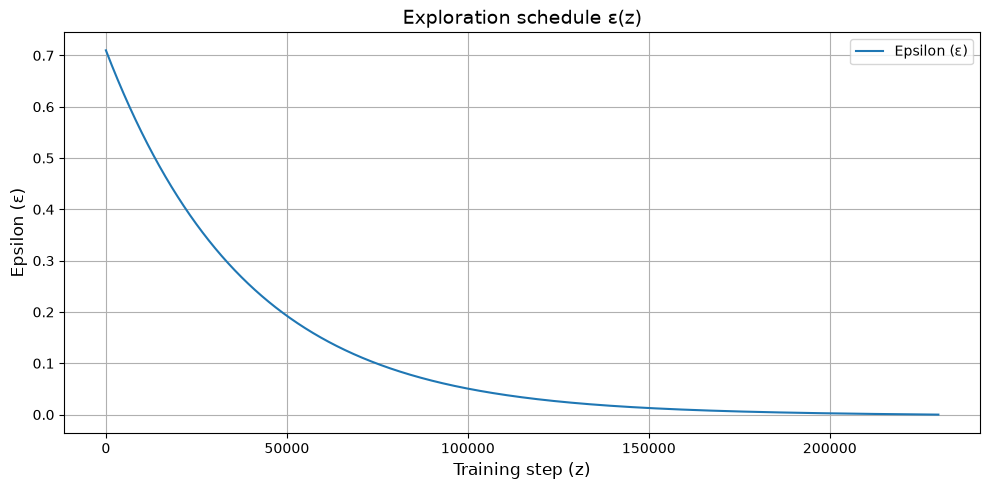

In [4]:
import matplotlib.pyplot as plt

# Visualise the epsilon (exploration) schedule used in Qlearn.
n_steps = 230_000
z_values = range(n_steps)
eps_values = [(0.7 * np.exp(-5 * z / n_steps) + 0.01) * max(0.0, 1 - z / n_steps) for z in z_values]

plt.figure(figsize=(10, 5))
plt.plot(z_values, eps_values, label="Epsilon (ε)")
plt.xlabel("Training step (z)", fontsize=12)
plt.ylabel("Epsilon (ε)", fontsize=12)
plt.title("Exploration schedule ε(z)", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# ===== TRAINING =====
checkpoint_filename = 'Q_learning_DATA_v64.pkl'   # file the best Q-table is saved to

print("\n--- START TRAINING ---")
nvec_angle = 120
nvec_rps = 50
max_episode_steps_train = 300

# Build the training environment: base env -> reset-normaliser -> time limit -> discretiser
env_train = UnbalancedDisk(dt=0.025, umax=3., render_mode=None)
env_train = UnbalancedDiskResetWrapper(env_train)
env_train = gym.wrappers.TimeLimit(env_train, max_episode_steps=max_episode_steps_train)
env_train = Discretize_obs(env_train, nvec=[nvec_angle, nvec_rps])

Qmat_trained, ep_lengths_steps, ep_lengths, ep_rewards = Qlearn(
    env_train,
    nsteps=350_000,                      # number of training steps
    nvec_angle=nvec_angle,
    nvec_rps=nvec_rps,
    callbackfeq=5000,
    checkpoint_name=checkpoint_filename,
)
env_train.close()

# sanity check that the checkpoint was written
if os.path.exists(checkpoint_filename):
    print(f"\nCheck: checkpoint '{checkpoint_filename}' found on disk.")
    import pickle
    with open(checkpoint_filename, 'rb') as f:
        loaded_Qmat_final_check = pickle.load(f)
    print(f"Loaded Qmat for final check. Size: {len(loaded_Qmat_final_check)} entries.")
else:
    print(f"\nCheck: checkpoint '{checkpoint_filename}' NOT found on disk.")



--- START TRAINING ---
Loaded initial Qmat from Q_learning_DATA_v64.pkl; continuing training.
step     300 | len 300 | reward    -90.2 | max  113 deg (top=180) | stalled below
step     600 | len 300 | reward    -92.6 | max  124 deg (top=180) | stalled below
step     900 | len 300 | reward    -97.2 | max   78 deg (top=180) | stalled below
step    1200 | len 300 | reward    -70.8 | max   57 deg (top=180) | stalled below
step    1500 | len 300 | reward    -75.1 | max  101 deg (top=180) | stalled below
step    1800 | len 300 | reward    -53.1 | max   71 deg (top=180) | stalled below
step    2100 | len 300 | reward    -49.3 | max  117 deg (top=180) | stalled below
#################################
 NEW BEST AVG REWARD (last 8 ep): -74.64, saved to Q_learning_DATA_v64.pkl
#################################
step    2400 | len 300 | reward    -68.7 | max   70 deg (top=180) | stalled below
#################################
 NEW BEST AVG REWARD (last 8 ep): -73.13, saved to Q_learning_DATA_v64.p

Last 10 episode rewards: [262.64278053 561.40300768 163.34591694 795.93641302 621.58585551
  63.86348703 668.15926389 617.93483191 499.17491361 719.89945842]


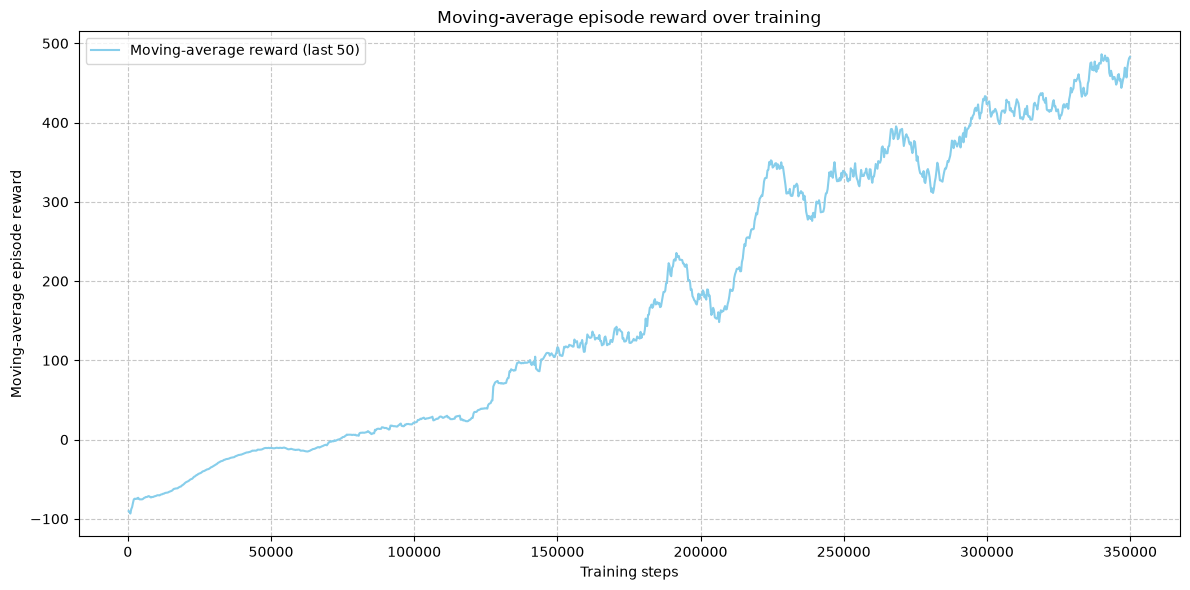

In [6]:
import matplotlib.pyplot as plt
import numpy as np

print(f"Last 10 episode rewards: {ep_rewards[-10:]}")
N_ROLLING_MEAN = 50
rolled_rewards = [np.mean(ep_rewards[max(0, i - N_ROLLING_MEAN + 1):i + 1]) for i in range(len(ep_rewards))]

plt.figure(figsize=(12, 6))
plt.plot(ep_lengths_steps, rolled_rewards, label=f'Moving-average reward (last {N_ROLLING_MEAN})', color='skyblue')
plt.legend()
plt.xlabel("Training steps")
plt.ylabel("Moving-average episode reward")
plt.title("Moving-average episode reward over training")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [9]:
# --- Evaluatie Fase: REPRODUCEERBAAR (deterministisch + vaste start onderaan) ---
print("\n--- START EVALUATION WITH BEST MODEL ---")
import pickle

checkpoint_filename = 'Q_learning_DATA_v64.pkl'
nvec_angle = 120                 # MOET gelijk zijn aan de training-cel
nvec_rps   = 50                  # MOET gelijk zijn aan de training-cel
eval_max_episode_steps = 300     # zelfde als tijdens training
TOP_TOL = 0.30                   # rad (~17 graden) -> "bij de top"
NUM_EVAL_EPISODES = 50           # meer episodes -> stabielere statistiek
EVAL_SEED = 0                    # vaste seed -> elke run identieke ruis/resultaat

best_Qmat = None
if os.path.exists(checkpoint_filename):
    with open(checkpoint_filename, 'rb') as f:
        best_Qmat = pickle.load(f)
    print(f"Loaded best Qmat from '{checkpoint_filename}' ({len(best_Qmat)} entries).")
else:
    print(f"Error: checkpoint '{checkpoint_filename}' not found. Train eerst.")


def make_eval_env(render_mode):
    e = UnbalancedDisk(dt=0.025, umax=3., render_mode=render_mode)
    e = UnbalancedDiskResetWrapper(e)
    e = gym.wrappers.TimeLimit(e, max_episode_steps=eval_max_episode_steps)
    e = Discretize_obs(e, nvec=[nvec_angle, nvec_rps])
    return e


def greedy_action(Qmat, obs, n):
    # DETERMINISTISCH: np.argmax pakt altijd de eerste max (geen willekeurige tie-break)
    return int(np.argmax([Qmat.get((obs, a), 0.0) for a in range(n)]))


def run_episode(env, Qmat, start=(0.0, 0.0), render=False, fps=30):
    """Eén greedy episode vanaf een VASTE start (default: stilstand onderaan)."""
    base = env.unwrapped
    base.set_th, base.set_omega = float(start[0]), float(start[1])   # forceer vaste startpositie
    obs, info = env.reset()
    base.set_th, base.set_omega = None, None                         # herstel
    total_r, steps, done, top_steps = 0.0, 0, False, 0
    while not done:
        action = greedy_action(Qmat, obs, env.action_space.n)
        obs, reward, terminated, truncated, info = env.step(action)
        total_r += reward
        steps += 1
        done = terminated or truncated
        err_top = abs(((base.th - np.pi + np.pi) % (2 * np.pi)) - np.pi)
        if err_top < TOP_TOL:
            top_steps += 1
        if render:
            env.render()
            time.sleep(1 / fps)
    ended_at_top = abs(((base.th - np.pi + np.pi) % (2 * np.pi)) - np.pi) < TOP_TOL
    return total_r, steps, top_steps / max(steps, 1), ended_at_top


if best_Qmat is not None:
    # Elke episode start vanaf stilstand onderaan (th=0, omega=0) -> zuivere swing-up test
    START = (0.0, 0.0)

    # 1) Statistische evaluatie (geen render -> snel). Seed -> volledig reproduceerbaar.
    np.random.seed(EVAL_SEED)
    env_stats = make_eval_env(render_mode=None)
    rewards, lengths, toptime, ended = [], [], [], []
    for _ in range(NUM_EVAL_EPISODES):
        r, l, ft, et = run_episode(env_stats, best_Qmat, start=START, render=False)
        rewards.append(r); lengths.append(l); toptime.append(ft); ended.append(et)
    env_stats.close()
    rewards = np.array(rewards); lengths = np.array(lengths); toptime = np.array(toptime)

    print(f"\n--- EVALUATION RESULTS over {NUM_EVAL_EPISODES} greedy episodes (deterministisch, start onderaan) ---")
    print(f"Reward       : mean {rewards.mean():8.2f} | std {rewards.std():7.2f} | "
          f"median {np.median(rewards):8.2f} | min {rewards.min():8.2f} | max {rewards.max():8.2f}")
    print(f"Length       : mean {lengths.mean():8.1f} | min {int(lengths.min())} | max {int(lengths.max())}")
    print(f"Tijd bij top : mean {100*toptime.mean():5.1f}%   <-- ECHTE kwaliteit (niet de reward)")
    print(f"Succes (eindigt bij top): {100*np.mean(ended):5.1f}% van de episodes")

    # 2) Een paar episodes met render om te kijken (ook vanaf onderaan)
    num_watch = 3
    np.random.seed(EVAL_SEED)
    env_watch = make_eval_env(render_mode='human')
    for i in range(num_watch):
        r, l, ft, et = run_episode(env_watch, best_Qmat, start=START, render=True)
        print(f"Watch episode {i+1}: length={l}, reward={r:.2f}, tijd-bij-top={100*ft:.0f}%")
    env_watch.close()
else:
    print("No best Qmat available for evaluation.")
# --- Einde van het Script ---



--- START EVALUATION WITH BEST MODEL ---
Loaded best Qmat from 'Q_learning_DATA_v64.pkl' (49416 entries).

--- EVALUATION RESULTS over 50 greedy episodes (deterministisch, start onderaan) ---
Reward       : mean   402.03 | std  188.29 | median   420.43 | min    96.75 | max   659.69
Length       : mean    300.0 | min 300 | max 300
Tijd bij top : mean  36.1%   <-- ECHTE kwaliteit (niet de reward)
Succes (eindigt bij top):  98.0% van de episodes
Watch episode 1: length=300, reward=614.04, tijd-bij-top=51%
Watch episode 2: length=300, reward=168.55, tijd-bij-top=21%
Watch episode 3: length=300, reward=263.05, tijd-bij-top=31%
